In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

datasets = {
    "Test 1": (np.array([0, 15, 30, 45, 60, 75, 90, 105, 117]), np.array([5.0, 4.0, 3.2, 2.3, 1.8, 1.3, 0.8, 0.4, 0]) * 10),
    "Test 2": (np.array([0, 15, 30, 45, 60, 75, 90, 105, 120, 135, 147]), np.array([4.9, 4.1, 3.5, 2.9, 2.3, 1.9, 1.5, 1.1, 0.6, 0.4, 0]) * 10),
    "Test 3": (np.array([0, 15, 30, 45, 60, 75, 90, 105, 120, 135, 150, 165, 166]), np.array([5.0, 4.2, 3.6, 3.0, 2.6, 2.1, 1.8, 1.5, 1.1, 0.8, 0.4, 0.2, 0]) * 10),
    "Test 4": (np.array([0, 15, 30, 45, 60, 75, 90, 105, 120, 135, 150, 165, 178]), np.array([5.2, 4.5, 3.9, 3.4, 2.9, 2.4, 2.0, 1.6, 1.3, 0.9, 0.6, 0.3, 0]) * 10),
    "Test 5": (np.array([0, 15, 30, 45, 60, 75, 90, 105, 120, 135, 150, 165, 180, 193]), np.array([5.1, 4.5, 3.9, 3.4, 3.0, 2.5, 2.1, 1.8, 1.5, 1.2, 0.9, 0.6, 0.3, 0]) * 10),
    "Test 6": (np.array([0, 15, 30, 45, 60, 75, 90, 105, 120, 135, 150, 165, 180, 194]), np.array([5.0, 4.4, 3.8, 3.3, 2.8, 2.5, 2.1, 1.8, 1.5, 1.2, 0.9, 0.7, 0.4, 0]) * 10),
    "Test 7": (np.array([0, 15, 30, 45, 60, 75, 90, 105, 120, 135, 150, 165, 180, 195, 208]), np.array([5.2, 4.6, 4.1, 3.6, 3.3, 2.8, 2.4, 2.0, 1.8, 1.5, 1.2, 0.9, 0.7, 0.5, 0]) * 10)}


Test 1: [0.014876236754280651, 0.014876236754280651, 0.022016112458038455, 0.016341497202198994, 0.021694826695641864, 0.032367187718780055, 0.046209812037329684]
Test 1 gem k/l: 0.024055

Test 2: [0.011883215427087918, 0.01054826701432628, 0.012536815433529308, 0.015453440937154958, 0.012737015784180615, 0.01575925187094869, 0.020676995220255963, 0.04040905357135437, 0.02703100720721096]
Test 2 gem k/l: 0.018559

Test 3: [0.011623559142985183, 0.010276711988483891, 0.012154770452930307, 0.009540056242711549, 0.01423827335320394, 0.010276711988483891, 0.012154770452930307, 0.020676995220255963, 0.02123024874123564, 0.046209812037329684, 0.046209812037329684]
Test 3 gem k/l: 0.019508

Test 4: [0.009638748587407165, 0.009540056242711549, 0.00914674143423233, 0.010604312975312485, 0.012616133309235222, 0.012154770452930307, 0.014876236754280651, 0.013842624318549636, 0.024514985341687823, 0.02703100720721096, 0.046209812037329684]
Test 4 gem k/l: 0.017289

Test 5: [0.008344209530267066, 

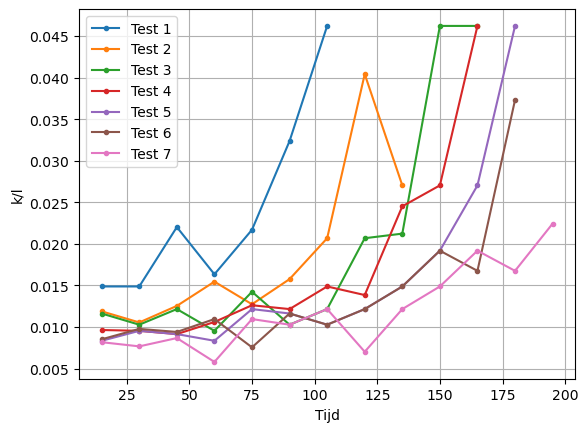

In [19]:
kl_totaal = []
labels = []

for naam, (t, h) in datasets.items():

    kl_local = []
    t_mid = []

    for j in range(1, len(t)):

        dt = t[j] - t[j-1]
        h_prev = h[j-1]
        h_curr = h[j]

        if h_curr <= 0 or h_prev <= 0:
            continue

        kl = np.log(h_prev / h_curr) / dt

        t_mid.append(t[j])
        kl_local.append(kl)

    kl_totaal.append(kl_local)
    labels.append(naam)

    plt.plot(t_mid, kl_local, marker='.', linewidth=1.5, label=naam)

    print(f"\n{naam}: {kl_local}")
    print(f"{naam} gem k/l: {np.mean(kl_local):.6f}")

plt.xlabel("Tijd")
plt.ylabel("k/l")
plt.legend()
plt.grid(True)
plt.show()

Test 1: mediaan = 0.021695
Test 2: mediaan = 0.015453
Test 3: mediaan = 0.012155
Test 4: mediaan = 0.012616
Test 5: mediaan = 0.011889
Test 6: mediaan = 0.011289
Test 7: mediaan = 0.010954


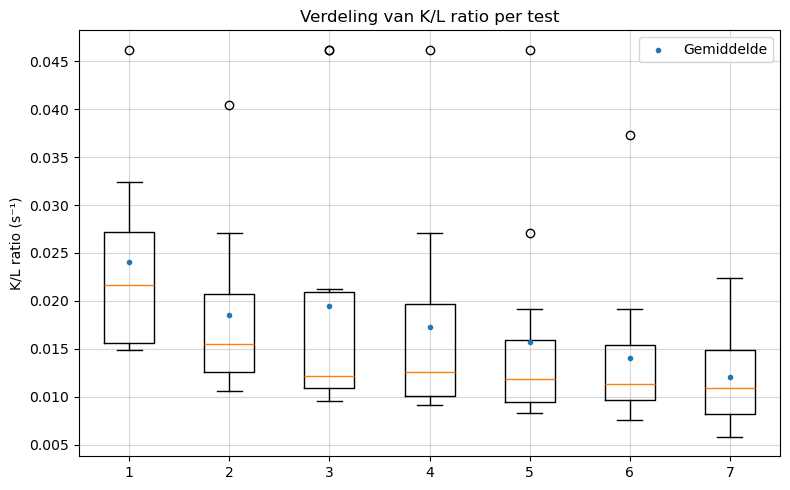

In [33]:
plt.figure(figsize=(8,5))

plt.boxplot(kl_totaal)

means = [np.mean(i) for i in kl_totaal]
plt.scatter(range(1, len(means)+1), means, marker='.', zorder=3, label='Gemiddelde')

for label, data in zip(labels, kl_totaal):
    mediaan = np.median(data)
    print(f"{label}: mediaan = {mediaan:.6f}")

plt.title('Verdeling van K/L ratio per test')
plt.ylabel('K/L ratio (s⁻¹)')
plt.grid(True, linestyle='-', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()